In [1]:
import numpy as np

from model_ranking import load_transfer_metric_results
from model_ranking import plot_performance_vs_transfer_metric

from model_ranking import calculate_correlation_statistics
from model_ranking import (
    transfer_results_to_arrays,
)

INFO: P [MainThread] 2025-08-14 09:42:26,834 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


In [2]:
GBC_path = "/scratch/talks/sampled_features/semantic_segmentation/mitochondria/transfer_metric_results/mitochondria_GBC.json"

GBC_results = load_transfer_metric_results(GBC_path)
GBC_scores = GBC_results["transfer_scores"]
performance_scores = GBC_results["performance_scores"]
correlation_scores = GBC_results["correlation_scores"]

Loaded Transfer metric results from: /scratch/talks/sampled_features/semantic_segmentation/mitochondria/transfer_metric_results/mitochondria_GBC.json
Experiment: mitochondria_GBC
Targets: 4 (EPFL, Hmito, Rmito, VNC)
Source models: 15
Total transfers: 57


Target: EPFL


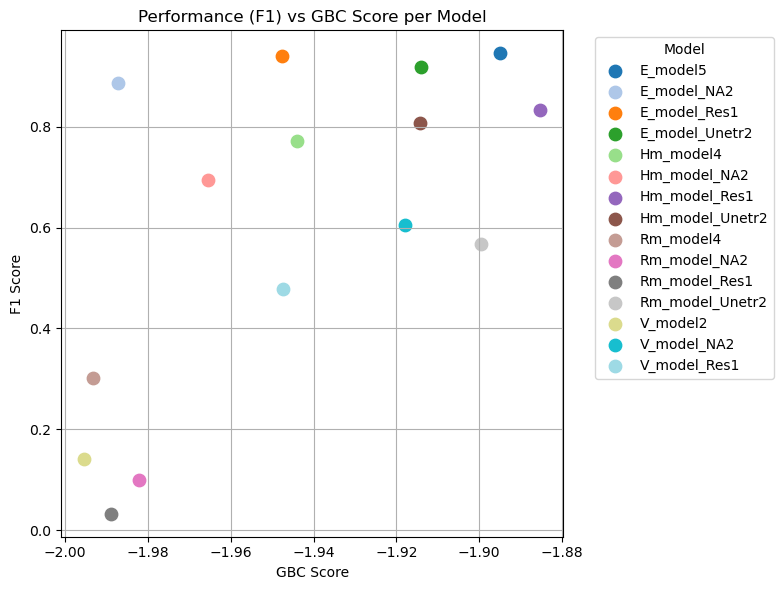

Target: Hmito


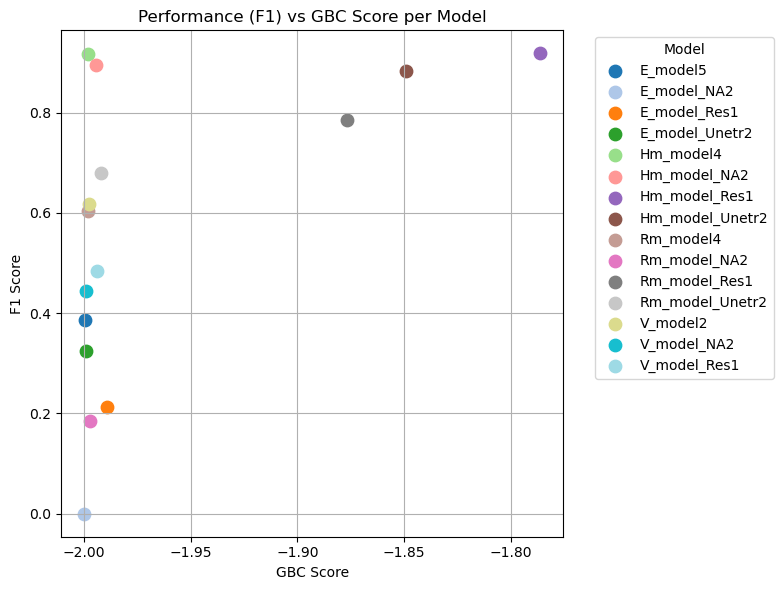

Target: Rmito


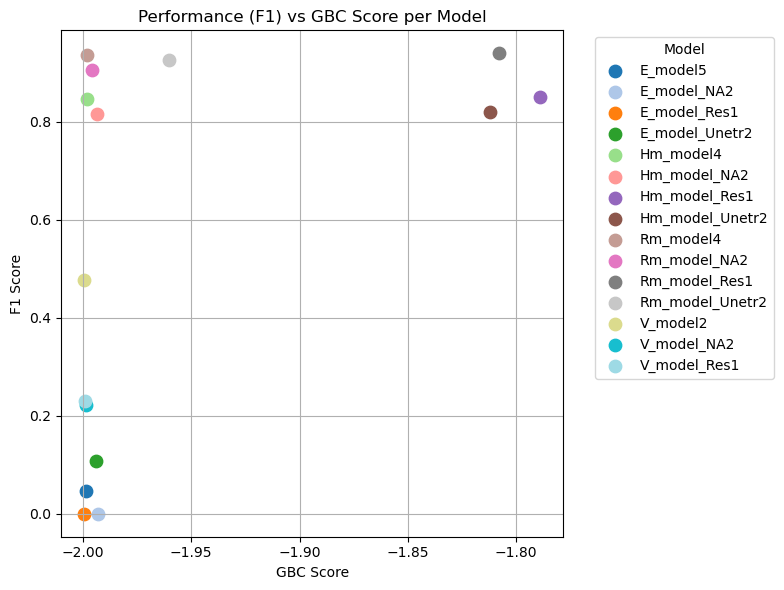

Target: VNC


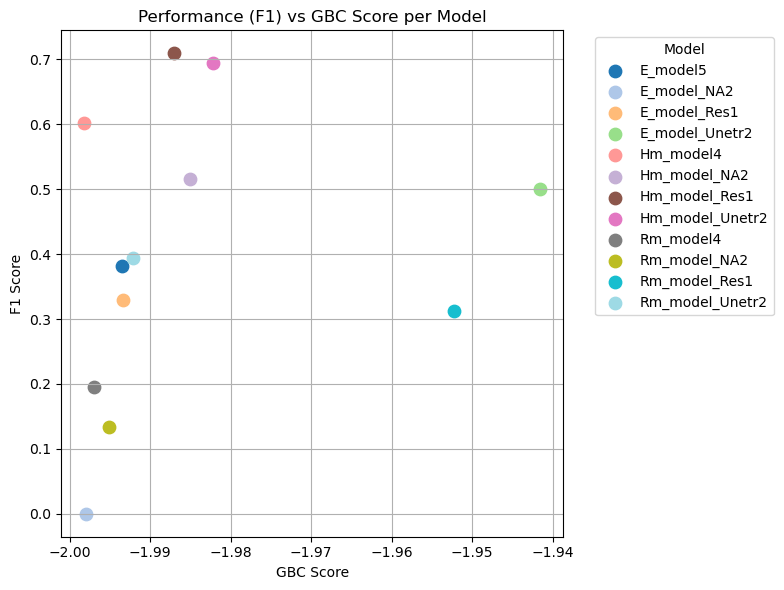

In [3]:
for target, scores_per_model in GBC_scores.items():
    print(f"Target: {target}")
    plot_performance_vs_transfer_metric(performance_scores[target], scores_per_model)

In [10]:
import pandas as pd
idx = 0
per_target_KT = np.array(correlation_scores["KT"])
per_target_SP = np.array(correlation_scores["SP"])
per_target_PE = np.array(correlation_scores["PE"])
df = pd.DataFrame(
    {
        "kt": per_target_KT[:, idx, 0], 
        "kt pval": per_target_KT[:, idx, 1], 
        "s rho": per_target_SP[:, idx, 0], 
        "s rho pval": per_target_SP[:, idx, 1], 
        "pr": per_target_PE[:, idx, 0], 
        "pr pval": per_target_PE[:, idx, 1]
    },
)
df["targets"] = GBC_results["metadata"]["targets"]
df = df.set_index("targets")
df.index = pd.MultiIndex.from_product([["Mito"], df.index], names=["Task", "targets"])
# Round all float columns to 2 significant figures
df = df.map(lambda x: round(x, 2) if isinstance(x, float) else x)
print(df)

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.65     0.01   0.60        0.01  0.45     0.02
     Hmito    0.54     0.04   0.54        0.04  0.43     0.04
     Rmito    0.47     0.08   0.51        0.06  0.34     0.09
     VNC      0.23     0.48   0.41        0.17  0.33     0.15
